In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("winequality-red.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (1599, 12)


In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
print(df.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [8]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 240


In [9]:
## Check Quality Distribution

print("Wine Quality Distribution:")
print(df['quality'].value_counts().sort_index())

Wine Quality Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


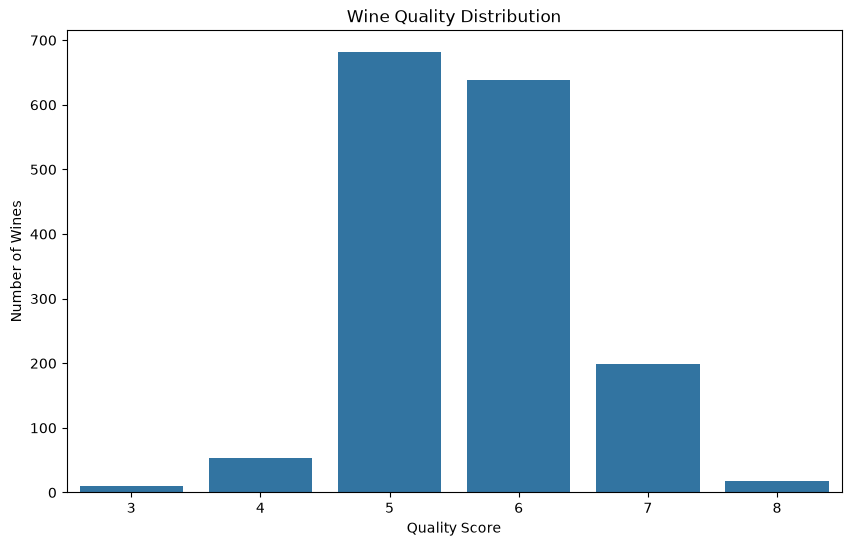

In [10]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='quality'
)

plt.title('Wine Quality Distribution')
plt.xlabel('Quality Score')
plt.ylabel('Number of Wines')

plt.show()

In [ ]:
## Quality Distribution

The target variable `quality` represents the sensory quality score of the wine. The distribution shows how many wines belong to each quality score.

The classes are not evenly distributed, so class imbalance should be considered when evaluating the classification model.

In [12]:
## Correlation with Quality
correlation = df.corr(numeric_only=True)['quality'].sort_values(
    ascending=False
)


print(correlation)

quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


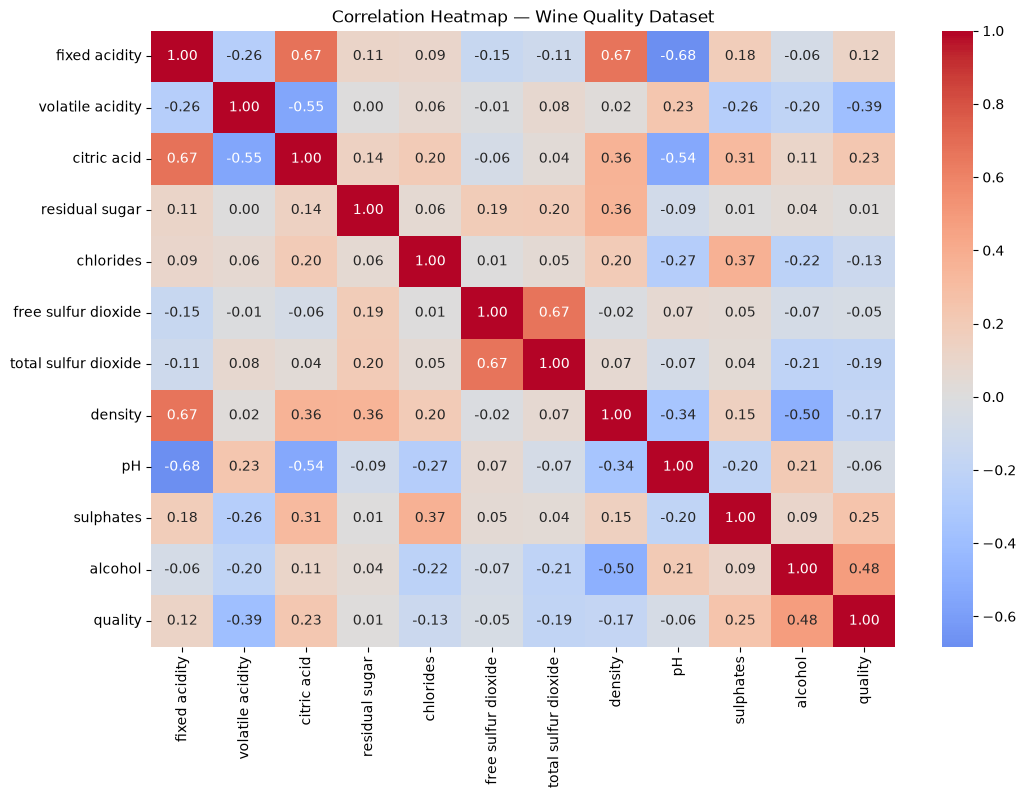

In [13]:
## Correlation Heatmap
plt.figure(figsize=(12, 8))


sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)


plt.title('Correlation Heatmap — Wine Quality Dataset')


plt.show()

In [14]:
## Remove Duplicate Rows

print("Before removing duplicates:", df.shape)

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Before removing duplicates: (1599, 12)
After removing duplicates: (1359, 12)
Remaining duplicate rows: 0


In [15]:
## Check Quality Distribution Again


print("Quality distribution after duplicate removal:")
print(df['quality'].value_counts().sort_index())

Quality distribution after duplicate removal:
quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64


In [16]:
## Create the Target Variable
df['quality_label'] = df['quality'].apply(
    lambda x: 1 if x >= 6 else 0
)

print(df['quality_label'].value_counts())

quality_label
1    719
0    640
Name: count, dtype: int64


In [17]:
print("Not Good wines:", (df['quality_label'] == 0).sum())
print("Good wines:", (df['quality_label'] == 1).sum())

Not Good wines: 640
Good wines: 719


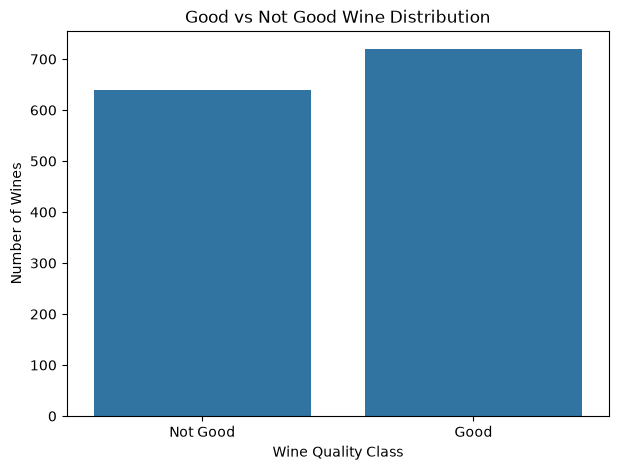

In [18]:
# Check the New Target
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='quality_label'
)

plt.title('Good vs Not Good Wine Distribution')
plt.xlabel('Wine Quality Class')
plt.ylabel('Number of Wines')

plt.xticks(
    [0, 1],
    ['Not Good', 'Good']
)

plt.show()

In [ ]:
## Target Variable

The original `quality` score ranges from 3 to 8. For binary classification, the quality scores were converted into two classes.

- Quality 3–5: Not Good (0)
- Quality 6–8: Good (1)

This transformation allows the classification model to predict whether a wine belongs to the Good or Not Good category.

In [19]:
## Separate Features and Target

## We don't want the original quality column to be used as an input because it is the value we're trying to predict.

X = df.drop(
    columns=['quality', 'quality_label']
)


y = df['quality_label']


print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1359, 11)
Target shape: (1359,)


In [21]:
## Train/Test Split

## Use 80% for training and 20% for testing.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1087, 11)
Testing features: (272, 11)
Training target: (1087,)
Testing target: (272,)


In [22]:
## Standardize Features
## Wine features have very different scales, so we'll standardize them.

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("Feature scaling completed.")

Feature scaling completed.


In [24]:
## Train Logistic Regression Model
## Now train the classification model:

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [25]:
## Make Predictions
y_pred = model.predict(X_test_scaled)


print("Predictions generated successfully!")
print(y_pred[:20])

Predictions generated successfully!
[1 0 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 0 1 1]


In [26]:
## Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 0.7353
Accuracy: 73.53%


In [27]:
## Classification Report

from sklearn.metrics import classification_report


print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Not Good', 'Good']
    )
)

Classification Report:
              precision    recall  f1-score   support

    Not Good       0.71      0.74      0.73       128
        Good       0.76      0.73      0.74       144

    accuracy                           0.74       272
   macro avg       0.73      0.74      0.73       272
weighted avg       0.74      0.74      0.74       272



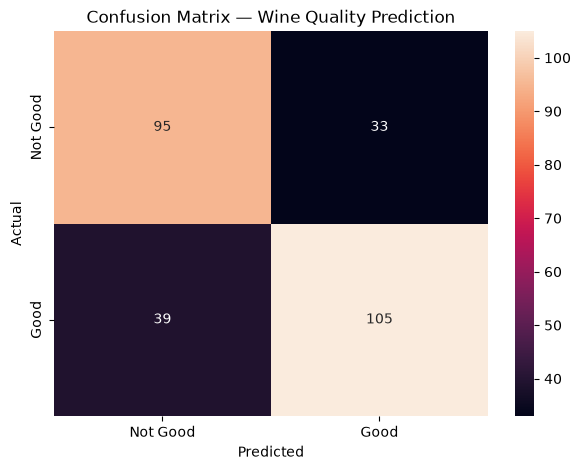

In [28]:
## Confusion Matrix

from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(7, 5))


sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Not Good', 'Good'],
    yticklabels=['Not Good', 'Good']
)


plt.title('Confusion Matrix — Wine Quality Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')


plt.show()

In [29]:
## Feature Coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})


coefficients['Absolute_Coefficient'] = (
    coefficients['Coefficient'].abs()
)


coefficients = coefficients.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)


coefficients

,Feature,Coefficient,Absolute_Coefficient
10,alcohol,0.986950,0.986950
6,total sulfur dioxide,-0.517825,0.517825
9,sulphates,0.477008,0.477008
1,volatile acidity,-0.476884,0.476884
4,chlorides,-0.217035,0.217035
0,fixed acidity,0.195495,0.195495
5,free sulfur dioxide,0.183192,0.183192
2,citric acid,-0.139338,0.139338
7,density,-0.076281,0.076281
8,pH,-0.074254,0.074254


In [30]:
print("Top 10 Important Features:")
print(coefficients.head(10))

Top 10 Important Features:
                 Feature  Coefficient  Absolute_Coefficient
10               alcohol     0.986950              0.986950
6   total sulfur dioxide    -0.517825              0.517825
9              sulphates     0.477008              0.477008
1       volatile acidity    -0.476884              0.476884
4              chlorides    -0.217035              0.217035
0          fixed acidity     0.195495              0.195495
5    free sulfur dioxide     0.183192              0.183192
2            citric acid    -0.139338              0.139338
7                density    -0.076281              0.076281
8                     pH    -0.074254              0.074254


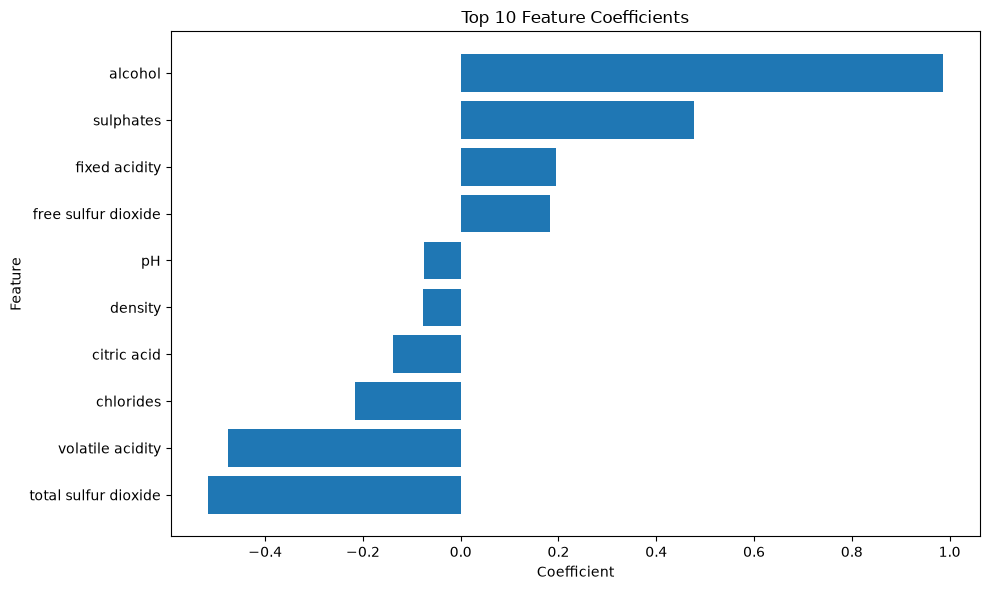

In [31]:
## Feature Importance Chart

top_features = coefficients.head(10).sort_values(
    by='Coefficient'
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Coefficient']
)

plt.title('Top 10 Feature Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')


plt.tight_layout()
plt.show()

In [ ]:
## Feature Coefficient Analysis

The Logistic Regression coefficients indicate the direction and strength of the relationship between each standardized feature and the probability of a wine being classified as Good.

Positive coefficients indicate that higher values of the feature are associated with a higher probability of being classified as Good, while negative coefficients indicate the opposite relationship.

The coefficient magnitude can be used to identify features that have a stronger influence on the model's predictions.

In [ ]:
## Confusion Matrix Interpretation

The confusion matrix shows how well the Logistic Regression model distinguishes between Good and Not Good wines.

The model makes predictions for both classes, with an overall accuracy of 73.53%. The classification report shows relatively balanced performance between the two classes, with an F1-score of 0.73 for Not Good wines and 0.74 for Good wines.

This indicates that the model performs reasonably consistently across both classes, although there is still room for improvement.

In [ ]:
## Model Performance

The Logistic Regression model achieved an accuracy of **73.53%** on the test dataset.

The model achieved:

- Precision of 0.71 and recall of 0.74 for Not Good wines.
- Precision of 0.76 and recall of 0.73 for Good wines.
- F1-score of 0.73 for Not Good wines.
- F1-score of 0.74 for Good wines.

The relatively similar performance between the two classes indicates that the model is not strongly biased toward one class.

In [ ]:
## Feature Analysis

The Logistic Regression coefficients provide insight into which standardized physicochemical features have the strongest influence on the classification result.

The largest positive coefficient belongs to **alcohol (0.987)**, indicating that higher standardized alcohol values are associated with a greater probability of a wine being classified as Good by the model.

**Sulphates (0.477)** also has a positive coefficient.

In contrast, **total sulfur dioxide (-0.518)** and **volatile acidity (-0.477)** have relatively large negative coefficients, indicating an inverse relationship with the probability of being classified as Good.

The coefficients should be interpreted as model relationships rather than proof of direct causation.

In [ ]:
# Conclusion

This project developed a wine quality classification model using the Wine Quality dataset.

The original dataset contained 1,599 records and 12 columns. There were no missing values, while 240 duplicate rows were identified and removed, resulting in 1,359 records.

The original wine quality scores were converted into a binary classification problem:

- Quality 3–5: Not Good
- Quality 6–8: Good

The dataset was divided into training and testing sets using an 80/20 stratified split. The 11 physicochemical features were standardized using StandardScaler, and a Logistic Regression model was trained.

The model achieved an accuracy of **73.53%** on the test dataset. The F1-scores were **0.73** for Not Good wines and **0.74** for Good wines.

Feature coefficient analysis showed that alcohol had the strongest positive coefficient, while total sulfur dioxide had the strongest negative coefficient.

Overall, the project demonstrates the use of data cleaning, feature engineering, feature scaling, Logistic Regression, classification metrics, confusion matrix analysis, and coefficient interpretation for wine quality prediction.